# Load Skeletons (from cache)

Reloads a `BrainDataset` previously saved by `load_skeletons.ipynb` via `dataset.save(...)`. Skips the expensive SWC read + graph-building pass.

### Imports

In [1]:
import numpy as np
import os

from agentic_neuron_proofreader.utils import img_util, util
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

## Section 1: Load From Cache

In [2]:
brain_id = "794495"
segmentation_id = "raw.unet_449_splits_and_merges_900000"

cache_path = f"../dataset_cache_{brain_id}.pkl"
dataset = BrainDataset.load_from_cache(cache_path)

segmentation_path = f"gs://allen-nd-goog/from_google/{brain_id}/whole_brain/{segmentation_id}/"
segmentation = img_util.TensorStoreImage(segmentation_path)

print(dataset.fragments_graph.summary(prefix="Fragments"))
print(dataset.gt_graph.summary(prefix="GroundTruth"))

I0528 14:07:00.136874  998641 google_auth_provider.cc:149] Using credentials at zihan_gcs_token.json
I0528 14:07:00.160032  998641 google_auth_provider.cc:165] Using ServiceAccount AuthProvider


Fragments Graph
# Connected Components: 10,172
# Nodes: 4,281,310
# Edges: 4,271,138
Memory Consumption: 29.32 GBs
GroundTruth Graph
# Connected Components: 19
# Nodes: 1,363,808
# Edges: 1,363,789
Memory Consumption: 29.32 GBs


### Combined Visualization: Image + UNet Segmentation + Skeletons

GT nodes / edges / components in patch:        326 / 324 / 1
Fragment nodes / edges / components in patch:  297 / 295 / 2
Seg volume: 105 unique segment IDs, 94,387 labeled voxels / 134,217,728 total (0.1% coverage)


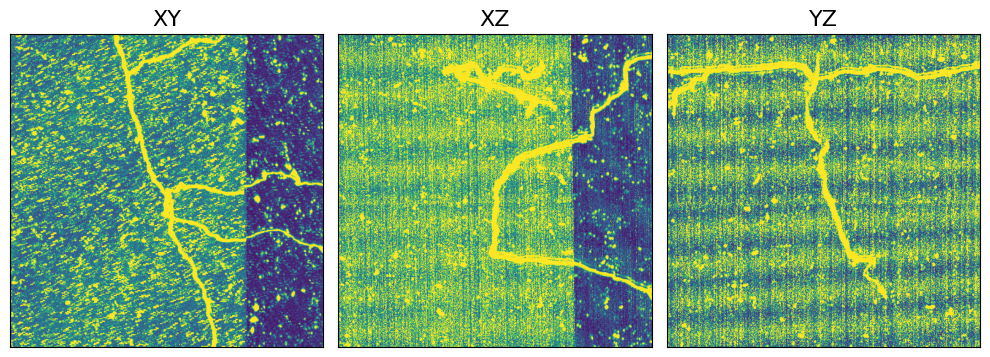

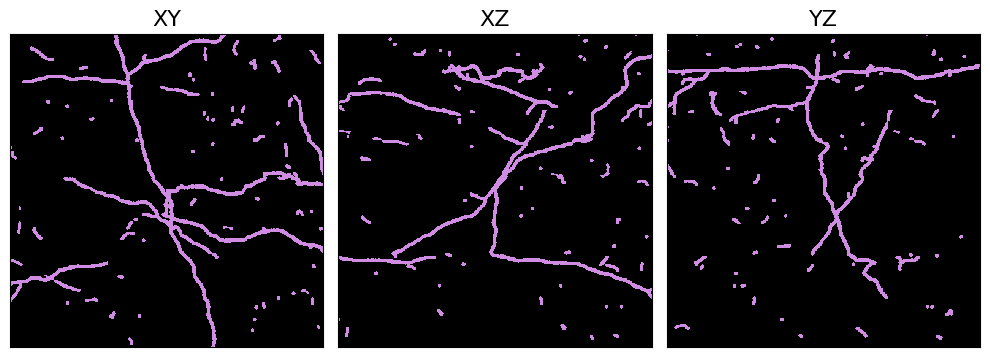

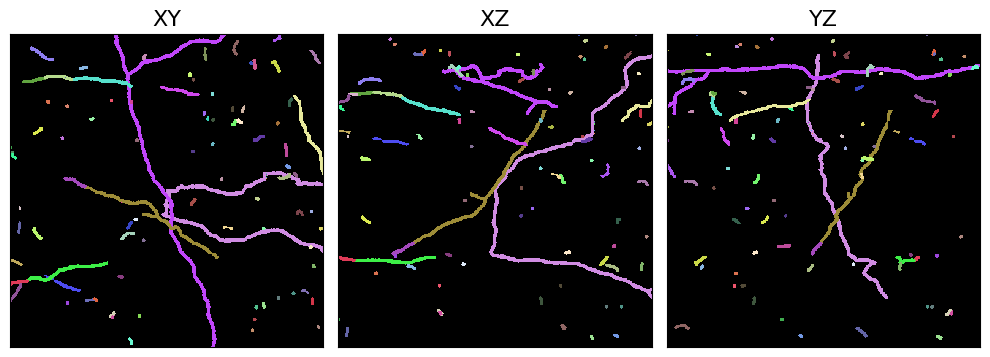

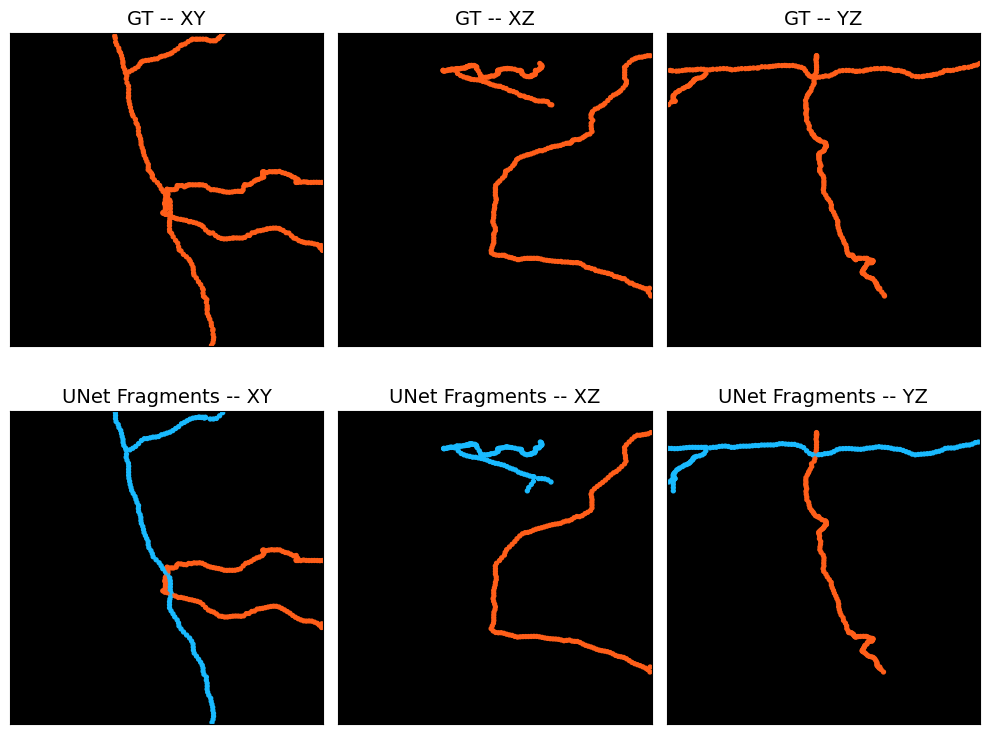


Figures saved to figs/


In [10]:
# Parameters
patch_shape = (512, 512, 512) 
use_groundtruth = True

# Sample a center voxel from either GT or UNet fragments graph
src_graph = dataset.gt_graph if use_groundtruth else dataset.fragments_graph
node = util.sample_once(src_graph.nodes)
center_voxel = src_graph.node_voxel(node)

# Three data sources visualized below:
#
# 1. img_patch: Raw microscopy image (the actual brain scan)
#
# 2. seg_patch / seg_mask: UNet segmentation VOLUME — the model's per-voxel
#    prediction of which segment each voxel belongs to. Label 0 = background
#    (no neuron detected). This is what GT nodes are labeled against for
#    computing skeleton metrics.
#
# 3. Skeletons (two independent sets, plotted on separate rows):
#    - "GT" (Ground Truth): Manually traced neuron skeletons (the answer key).
#      19 neurons, from human-annotated SWC files.
#    - "UNet Fragments": Skeletons extracted FROM the UNet segmentation volume.
#      10,172 fragments — one skeleton per connected component in seg_patch.
#      These are NOT directly used in edge classification metrics; they are
#      only used for merge detection (checking if a single fragment spans
#      multiple GT neurons).

img_patch = dataset.img.read(center_voxel, patch_shape)
seg_patch = segmentation.read(center_voxel, patch_shape)
seg_mask = (seg_patch > 0).astype(int)

# Remap seg_patch to consecutive IDs for fast colormap creation.
# Raw segment IDs can be very large (e.g. 500000+), which makes
# make_segmentation_colormap allocate a huge array. Remapping to 0..N
# keeps the colormap small while preserving distinct colors per segment.
unique_ids, seg_patch_remapped = np.unique(seg_patch, return_inverse=True)
seg_patch_remapped = seg_patch_remapped.reshape(seg_patch.shape).astype(np.int32)

# Patch origin in global voxel space (for converting global -> local coords)
offset = tuple(c - s // 2 for c, s in zip(center_voxel, patch_shape))

# Find skeleton nodes + edges inside the patch.
gt_nodes, gt_node_comps = dataset.gt_graph.nodes_in_patch(
    offset, patch_shape, return_components=True
)
gt_edges, gt_edge_comps = dataset.gt_graph.edges_in_patch(
    offset, patch_shape, return_components=True
)
frag_nodes, frag_node_comps = dataset.fragments_graph.nodes_in_patch(
    offset, patch_shape, return_components=True
)
frag_edges, frag_edge_comps = dataset.fragments_graph.edges_in_patch(
    offset, patch_shape, return_components=True
)

# Segmentation volume stats in patch
n_seg_ids = len(unique_ids[unique_ids > 0])  # Exclude background (0)
seg_voxels = np.sum(seg_patch > 0)
total_voxels = np.prod(patch_shape)

print(f"GT nodes / edges / components in patch:        "
      f"{len(gt_nodes)} / {len(gt_edges)} / {len(np.unique(gt_node_comps))}")
print(f"Fragment nodes / edges / components in patch:  "
      f"{len(frag_nodes)} / {len(frag_edges)} / {len(np.unique(frag_node_comps))}")
print(f"Seg volume: {n_seg_ids} unique segment IDs, "
      f"{seg_voxels:,} labeled voxels / {total_voxels:,} total "
      f"({seg_voxels/total_voxels*100:.1f}% coverage)")

import matplotlib.pyplot as plt

# Save figures to figs/ directory
figs_dir = "../figs"
os.makedirs(figs_dir, exist_ok=True)

# Hook into matplotlib to save each figure before it's displayed.
# We monkey-patch plt.show temporarily to also call savefig.
_fig_counter = [0]
_fig_names = ["image_mip", "segmentation_binary_mip", "segmentation_color_mip", "skeleton_mip"]
_original_show = plt.show

def _saving_show(*args, **kwargs):
    fig = plt.gcf()
    name = _fig_names[_fig_counter[0]] if _fig_counter[0] < len(_fig_names) else f"fig_{_fig_counter[0]}"
    fig.savefig(os.path.join(figs_dir, f"{name}.png"), dpi=150, bbox_inches="tight")
    _fig_counter[0] += 1
    _original_show(*args, **kwargs)

plt.show = _saving_show

# Plot 1: Raw image MIP
img_util.plot_mips(img_patch)
# Plot 2: UNet segmentation volume (binary mask: segment vs background)
img_util.plot_segmentation_mips(seg_mask)
# Plot 3: UNet segmentation volume — each segment ID shown as a different color.
# This is the VOLUME that determines split/omit metrics (not the fragment skeletons).
# Different colors = different segments. If a GT neuron crosses a color boundary,
# that's a split error. Uses remapped IDs for fast rendering.
img_util.plot_segmentation_mips(seg_patch_remapped)
# Plot 4: Skeletons — GT (human-traced) and UNet fragments (auto-extracted)
# on separate rows. Each connected component gets its own color.
# UNet fragments are skeletons extracted FROM seg_patch — they correspond to
# the colored regions above, but colors won't match (independent palettes).
img_util.plot_skeleton_mips(
    {
        "GT": {
            "nodes": gt_nodes,
            "node_components": gt_node_comps,
            "edges": gt_edges,
            "components": gt_edge_comps,
            "color": "lime",
        },
        "UNet Fragments": {
            "nodes": frag_nodes,
            "node_components": frag_node_comps,
            "edges": frag_edges,
            "components": frag_edge_comps,
            "color": "cyan",
        },
    },
    patch_shape,
    separate_rows=True,
)

# Restore original plt.show
plt.show = _original_show
print(f"\nFigures saved to {figs_dir}/")

3D segmentation saved to ../figs/segmentation_3d.html
  Points plotted: 11,396 (downsample=1x)
  Segments: 12


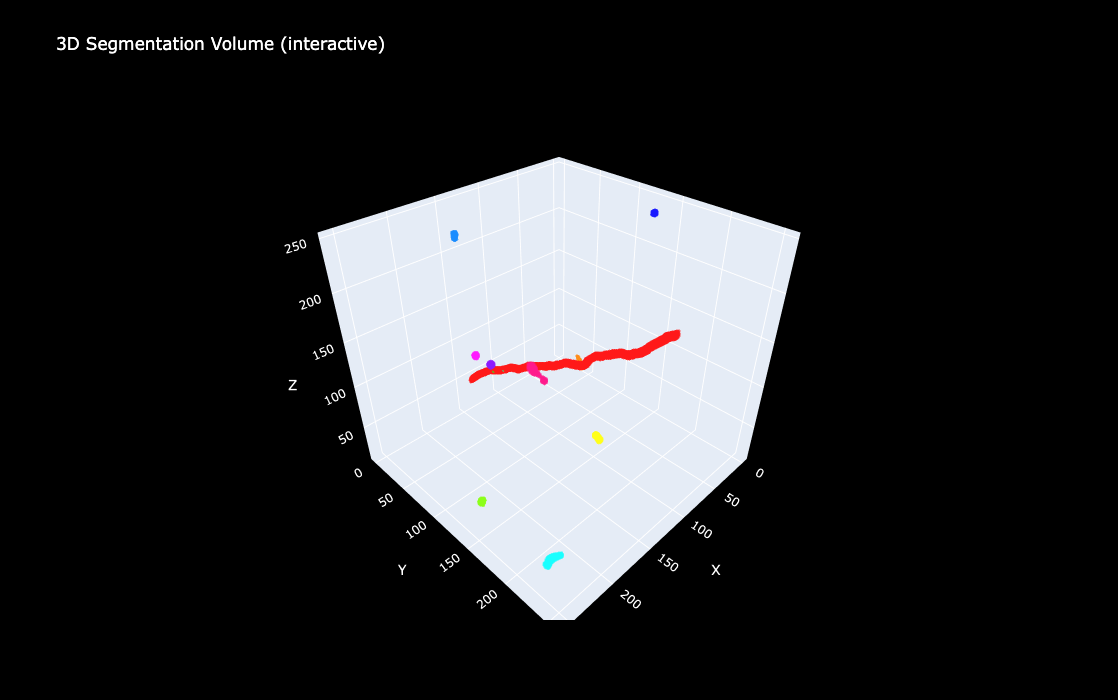

In [4]:
import plotly.graph_objects as go
import colorsys

def plot_segmentation_3d(seg_remapped, original_ids, downsample=4,
                         save_path="../figs/segmentation_3d.html"):
    """
    Interactive 3D plot of segmentation volume. Each segment shown as a
    different color. Saves as an HTML file that can be opened in a browser.

    Parameters
    ----------
    seg_remapped : ndarray
        Segmentation volume with consecutive integer labels (0 = background).
    original_ids : ndarray
        Mapping from remapped IDs back to original segment IDs (from np.unique).
    downsample : int
        Downsample factor to reduce point count for performance.
    save_path : str
        Path to save the interactive HTML file.
    """
    # Downsample to keep point count manageable
    seg_ds = seg_remapped[::downsample, ::downsample, ::downsample]

    # Get non-background voxel coordinates and their labels
    mask = seg_ds > 0
    coords = np.argwhere(mask)  # (N, 3) in (z, y, x)
    labels = seg_ds[mask]

    # Generate distinct colors per segment
    unique_labels = np.unique(labels)
    n_labels = len(unique_labels)
    colors_rgb = [colorsys.hsv_to_rgb(i / max(n_labels, 1), 0.9, 1.0)
                  for i in range(n_labels)]
    label_to_color = {int(lbl): colors_rgb[i] for i, lbl in enumerate(unique_labels)}

    point_colors = [
        f"rgb({int(label_to_color[int(l)][0]*255)},"
        f"{int(label_to_color[int(l)][1]*255)},"
        f"{int(label_to_color[int(l)][2]*255)})"
        for l in labels
    ]

    hover_text = [f"Segment {original_ids[int(l)]}" for l in labels]

    fig = go.Figure(data=[go.Scatter3d(
        x=coords[:, 2],  # x
        y=coords[:, 1],  # y
        z=coords[:, 0],  # z
        mode='markers',
        marker=dict(size=1.5, color=point_colors, opacity=0.6),
        text=hover_text,
        hoverinfo='text',
    )])

    fig.update_layout(
        title="3D Segmentation Volume (interactive)",
        scene=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
            bgcolor="black",
        ),
        paper_bgcolor="black",
        font=dict(color="white"),
        width=900, height=700,
    )

    os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else ".", exist_ok=True)
    fig.write_html(save_path)
    print(f"3D segmentation saved to {save_path}")
    print(f"  Points plotted: {len(coords):,} (downsample={downsample}x)")
    print(f"  Segments: {n_labels}")
    fig.show()

plot_segmentation_3d(seg_patch_remapped, unique_ids, downsample=1,
                     save_path="../figs/segmentation_3d.html")

### Patch-local Skeleton Metrics

**IMPORTANT DISTINCTION from the cell below:**

The next section shows **whole-brain metrics** for skeletons that have nodes in this patch. Those split/merge errors could have occurred anywhere in the brain, not necessarily in this patch.

This cell computes **patch-local metrics** — only counting errors that are actually visible in the current patch. Uses the **identical** edge classification logic as `segmentation_skeleton_metrics.skeleton_metrics`:

- **Split edge**: GT edge where the two endpoint labels differ AND both labels are non-empty (includes one endpoint in background "0" and the other in a segment — this counts as a split, not an omit!)
- **Omit edge**: GT edge where **BOTH** endpoints have label "0" (background)
- **Correct edge**: GT edge where both endpoints have the same non-empty label
- **Merge**: A UNet segment that contains GT nodes from >1 distinct GT skeleton (with >50 nodes from each, matching the metrics package threshold)
- **Edge Accuracy**: `100 - (% Split + % Omit + % Merged)` (same formula as `EdgeAccuracyMetric`)

This shows the actual segmentation quality within this specific patch.

In [5]:
from collections import defaultdict

# This follows the EXACT same edge classification logic as
# segmentation_skeleton_metrics.skeleton_metrics (SplitEdgePercentMetric,
# OmitEdgePercentMetric, MergedEdgePercentMetric, EdgeAccuracyMetric).
# Operates only on the current patch instead of the whole brain.

# Step 1: Get GT nodes in patch and label them with UNet segment IDs
# (Same as _label_graph() in graph_loading.py — labels each GT node by
# reading the segmentation at its voxel coordinate)
gt_local, gt_ids = dataset.gt_graph.nodes_in_patch(
    offset, patch_shape, return_ids=True
)

gt_local_int = np.round(gt_local).astype(int)
gt_local_int = np.clip(gt_local_int, 0, np.array(patch_shape) - 1)

# Label each GT node with its UNet segment ID (as string, matching the package)
gt_node_labels = seg_patch[
    gt_local_int[:, 0], gt_local_int[:, 1], gt_local_int[:, 2]
]
# Convert to string labels to match segmentation_skeleton_metrics convention
# where "0" = background, any other string = segment ID
gt_node_label_str = [str(int(lbl)) for lbl in gt_node_labels]

id_to_idx = {int(nid): i for i, nid in enumerate(gt_ids)}

# Step 2: Classify edges — EXACTLY matching the metrics package logic:
#
# From skeleton_metrics.py:
#   SplitEdgePercentMetric.count_split_edges (line 146-151):
#     is_different = graph.node_label[i] != graph.node_label[j]
#     is_nonzero = graph.node_label[i] and graph.node_label[j]
#     split if is_different AND is_nonzero
#
#   OmitEdgePercentMetric.count_omit_edges (line 211-215):
#     omit if graph.node_label[i] == "0" AND graph.node_label[j] == "0"
#
# Key: "0" is a truthy string in Python, so an edge with one endpoint "0"
# and the other a segment ID counts as SPLIT (not omit). Omit requires BOTH
# endpoints to be "0".

n_correct = n_split = n_omit = 0

for u, v in dataset.gt_graph.edges():
    if u in id_to_idx and v in id_to_idx:
        lu = gt_node_label_str[id_to_idx[u]]
        lv = gt_node_label_str[id_to_idx[v]]

        if lu == "0" and lv == "0":
            # Both endpoints in background → omit
            n_omit += 1
        elif lu != lv and lu and lv:
            # Different labels, both non-empty → split
            # (includes "0" vs "12345" since "0" is truthy)
            n_split += 1
        else:
            # Same non-empty label → correct
            n_correct += 1

# Step 3: Count merges — matching MergedEdgePercentMetric.detect_label_intersections
# A UNet segment is a "merge" if GT nodes from >1 GT component land on it,
# AND each component contributes >50 nodes (same threshold as the package,
# see skeleton_metrics.py line 293).
seg_to_components = defaultdict(lambda: defaultdict(int))
gt_comp = dataset.gt_graph.node_component_id

for i, nid in enumerate(gt_ids):
    label = gt_node_label_str[i]
    if label != "0":
        comp_id = int(gt_comp[int(nid)])
        seg_to_components[label][comp_id] += 1

# Count merged edges: edges where both endpoints share a label that is a merge
labels_with_merge = set()
for label, comp_counts in seg_to_components.items():
    # A merge requires >1 component with >50 nodes each in the same segment
    large_components = [c for c, cnt in comp_counts.items() if cnt > 50]
    if len(large_components) > 1:
        labels_with_merge.add(label)

n_merged_edges = 0
for u, v in dataset.gt_graph.edges():
    if u in id_to_idx and v in id_to_idx:
        lu = gt_node_label_str[id_to_idx[u]]
        lv = gt_node_label_str[id_to_idx[v]]
        if lu == lv and lu in labels_with_merge:
            n_merged_edges += 1

n_merges = len(labels_with_merge)

# Step 4: Compute derived metrics — matching EdgeAccuracyMetric (line 779-784):
#   edge_accuracy = 100 - (% Split + % Omit + % Merged)
n_edges = n_correct + n_split + n_omit

if n_edges > 0:
    pct_split = (n_split / n_edges) * 100
    pct_omit = (n_omit / n_edges) * 100
    pct_merged = (n_merged_edges / n_edges) * 100
    edge_accuracy = 100 - (pct_split + pct_omit + pct_merged)
else:
    pct_split = pct_omit = pct_merged = edge_accuracy = float('nan')

# Display results
print("Patch-local Skeleton Metrics (errors visible in this patch only)")
print("=" * 70)
print(f"GT nodes in patch:           {len(gt_ids)}")
print(f"GT edges fully in patch:     {n_edges}")
print()
print("Edge Classification:")
if n_edges > 0:
    print(f"  Correct:  {n_correct:4d}  ({n_correct/n_edges*100:5.1f}%)")
    print(f"  Split:    {n_split:4d}  ({pct_split:5.1f}%)")
    print(f"  Omit:     {n_omit:4d}  ({pct_omit:5.1f}%)")
    print(f"  Merged:   {n_merged_edges:4d}  ({pct_merged:5.1f}%)")
else:
    print("  No edges in patch.")
print()
print(f"Merge segments (>1 GT component with >50 nodes each): {n_merges}")
print()
if n_edges > 0:
    print(f"Edge Accuracy:    {edge_accuracy:.2f}%")
    print(f"% Split Edges:    {pct_split:.2f}%")
    print(f"% Omit Edges:     {pct_omit:.2f}%")
    print(f"% Merged Edges:   {pct_merged:.2f}%")
print()
print("Note: This shows only errors visible in the current patch,")
print("      unlike the whole-brain metrics shown below.")

Patch-local Skeleton Metrics (errors visible in this patch only)
GT nodes in patch:           63
GT edges fully in patch:     62

Edge Classification:
  Correct:    62  (100.0%)
  Split:       0  (  0.0%)
  Omit:        0  (  0.0%)
  Merged:      0  (  0.0%)

Merge segments (>1 GT component with >50 nodes each): 0

Edge Accuracy:    100.00%
% Split Edges:    0.00%
% Omit Edges:     0.00%
% Merged Edges:   0.00%

Note: This shows only errors visible in the current patch,
      unlike the whole-brain metrics shown below.


Edges by type:  correct=62  split=0  omit=0  merged=0
Nodes by type:  correct=63  split=0  omit=0  merged=0


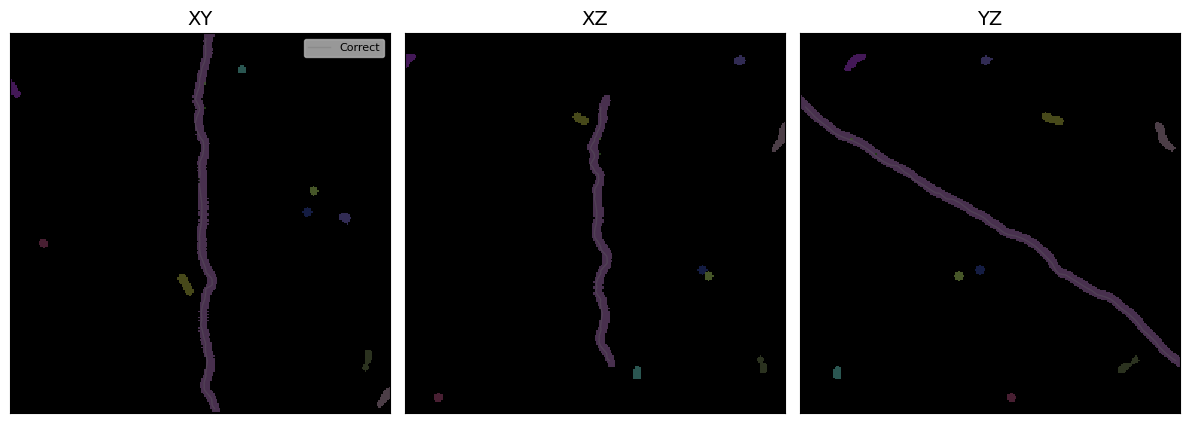

Error visualization saved to ../figs/skeleton_errors_mip.png


In [6]:
# Visualize GT edges and nodes with errors highlighted.
# Collect edges and nodes by classification type using local patch coordinates.

correct_edges = []
split_edges = []
omit_edges = []
merged_edges = []

# Classify nodes: a node is colored by its segment label
correct_nodes = []
split_nodes = []  # nodes involved in a split edge (label != neighbor's label)
omit_nodes = []   # nodes with label "0"
merged_nodes = [] # nodes with a merge label

# First, classify nodes by their own label
node_is_error = np.zeros(len(gt_ids), dtype=int)  # 0=correct, 1=split, 2=omit, 3=merged
for i, nid in enumerate(gt_ids):
    label = gt_node_label_str[i]
    if label == "0":
        node_is_error[i] = 2  # omit
    elif label in labels_with_merge:
        node_is_error[i] = 3  # merged

# Mark nodes involved in split edges
for u, v in dataset.gt_graph.edges():
    if u in id_to_idx and v in id_to_idx:
        lu = gt_node_label_str[id_to_idx[u]]
        lv = gt_node_label_str[id_to_idx[v]]
        edge_coords = np.array([gt_local[id_to_idx[u]], gt_local[id_to_idx[v]]])

        if lu == "0" and lv == "0":
            omit_edges.append(edge_coords)
        elif lu != lv and lu and lv:
            split_edges.append(edge_coords)
            # Mark both endpoints as involved in a split
            if node_is_error[id_to_idx[u]] == 0:
                node_is_error[id_to_idx[u]] = 1
            if node_is_error[id_to_idx[v]] == 0:
                node_is_error[id_to_idx[v]] = 1
        elif lu == lv and lu in labels_with_merge:
            merged_edges.append(edge_coords)
        else:
            correct_edges.append(edge_coords)

# Collect nodes by type
for i in range(len(gt_ids)):
    if node_is_error[i] == 0:
        correct_nodes.append(gt_local[i])
    elif node_is_error[i] == 1:
        split_nodes.append(gt_local[i])
    elif node_is_error[i] == 2:
        omit_nodes.append(gt_local[i])
    elif node_is_error[i] == 3:
        merged_nodes.append(gt_local[i])

correct_edges = np.array(correct_edges) if correct_edges else np.empty((0, 2, 3))
split_edges = np.array(split_edges) if split_edges else np.empty((0, 2, 3))
omit_edges = np.array(omit_edges) if omit_edges else np.empty((0, 2, 3))
merged_edges = np.array(merged_edges) if merged_edges else np.empty((0, 2, 3))

correct_nodes = np.array(correct_nodes) if correct_nodes else np.empty((0, 3))
split_nodes = np.array(split_nodes) if split_nodes else np.empty((0, 3))
omit_nodes = np.array(omit_nodes) if omit_nodes else np.empty((0, 3))
merged_nodes = np.array(merged_nodes) if merged_nodes else np.empty((0, 3))

print(f"Edges by type:  correct={len(correct_edges)}  split={len(split_edges)}  "
      f"omit={len(omit_edges)}  merged={len(merged_edges)}")
print(f"Nodes by type:  correct={len(correct_nodes)}  split={len(split_nodes)}  "
      f"omit={len(omit_nodes)}  merged={len(merged_nodes)}")

# Improved error visualization:
#   - Segmentation MIP as semi-transparent background (shows WHY errors occur)
#   - Correct edges dimmed to gray context lines
#   - Error edges highlighted with colored halos
#   - Error nodes drawn with white outlines for visibility
error_groups = {}
if len(split_edges) > 0 or len(split_nodes) > 0:
    error_groups["Split"] = {"nodes": split_nodes, "edges": split_edges, "color": "red"}
if len(omit_edges) > 0 or len(omit_nodes) > 0:
    error_groups["Omit"] = {"nodes": omit_nodes, "edges": omit_edges, "color": "yellow"}
if len(merged_edges) > 0 or len(merged_nodes) > 0:
    error_groups["Merged"] = {"nodes": merged_nodes, "edges": merged_edges, "color": "magenta"}

seg_cmap = img_util.make_segmentation_colormap(seg_patch_remapped)

_original_show = plt.show
def _save_error_fig(*args, **kwargs):
    fig = plt.gcf()
    fig.savefig(os.path.join(figs_dir, "skeleton_errors_mip.png"), dpi=150, bbox_inches="tight")
    _original_show(*args, **kwargs)
plt.show = _save_error_fig

img_util.plot_skeleton_errors(
    correct_edges,
    error_groups,
    patch_shape,
    seg_patch=seg_patch_remapped,
    seg_cmap=seg_cmap,
)

plt.show = _original_show
print(f"Error visualization saved to {figs_dir}/skeleton_errors_mip.png")

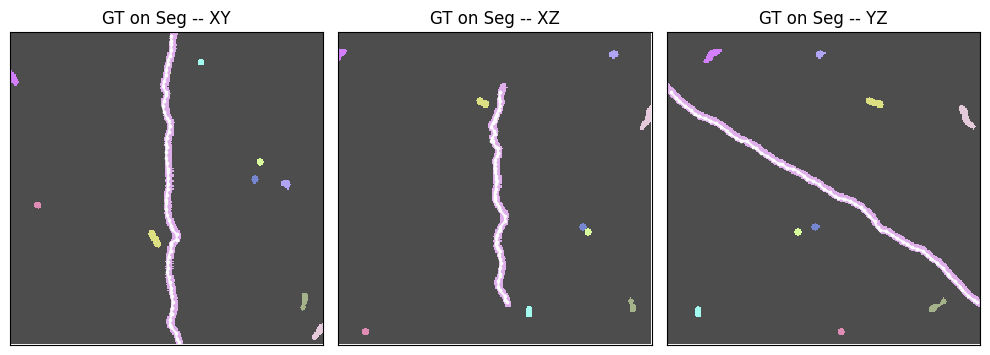

Overlay saved to ../figs/gt_on_segmentation_overlay.png


In [7]:
# Overlay GT skeleton on top of segmentation color MIP.
# This lets you visually verify: where the GT skeleton crosses a color boundary
# in the segmentation, you should see a split error in skeleton_errors_mip.
#
# Expected behavior:
# - GT skeleton should mostly run ALONG colored segments (correct)
# - Where the skeleton crosses from one color to another → split (red in errors plot)
# - Where the skeleton passes through black (background) → omit/split (yellow/red)
# - Colors WON'T match between the two layers (independent palettes)

from matplotlib.colors import ListedColormap

fig, axs = plt.subplots(1, 3, figsize=(10, 4))
axs_names = ["XY", "XZ", "YZ"]
plane_axes = [(1, 2), (0, 2), (0, 1)]

# Build colormap for segmentation (same as plot_segmentation_mips)
cmap = img_util.make_segmentation_colormap(seg_patch_remapped)

for i, (name, (a, b)) in enumerate(zip(axs_names, plane_axes)):
    ax = axs[i]
    
    # Draw segmentation color MIP as background
    seg_mip = np.max(seg_patch_remapped, axis=i)
    ax.imshow(seg_mip, cmap=cmap, interpolation="none", alpha=0.7)
    
    # Overlay GT skeleton edges (white for visibility on colored background)
    if len(gt_edges) > 0:
        from matplotlib.collections import LineCollection
        segs = np.stack([gt_edges[:, 0, [b, a]], gt_edges[:, 1, [b, a]]], axis=1)
        lc = LineCollection(segs, colors="white", linewidths=1.5, alpha=0.9)
        ax.add_collection(lc)
    
    # Overlay GT nodes
    if len(gt_nodes) > 0:
        ax.scatter(gt_nodes[:, b], gt_nodes[:, a], s=3, c="white", alpha=0.9)
    
    ax.set_xlim(0, patch_shape[b])
    ax.set_ylim(patch_shape[a], 0)
    ax.set_aspect("equal")
    ax.set_title(f"GT on Seg -- {name}", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, "gt_on_segmentation_overlay.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Overlay saved to {figs_dir}/gt_on_segmentation_overlay.png")

### Patch-level Skeleton Metrics

Loads pre-computed metrics from `evaluate_skeleton_metrics.ipynb` and displays
them in the context of the current patch. Shows which GT skeleton components
are present in the patch and reports the full-brain metrics (correct / split /
omit edges, merges, edge accuracy, etc.) from the evaluation output.

**Key features:**
- Uses pre-computed results from `metrics_out/{brain_id}/{segmentation_id}/results.csv`
- Identifies which GT component IDs fall within the current patch
- Displays per-skeleton metrics table and summary statistics
- No recomputation needed — leverages the full `segmentation-skeleton-metrics` pipeline

**Note:** Requires running `evaluate_skeleton_metrics.ipynb` first to generate the metrics CSV file.

In [8]:
import pandas as pd
import os

# Load the pre-computed metrics from evaluate_skeleton_metrics
metrics_dir = f"../metrics_out/{brain_id}/{segmentation_id}"
results_path = os.path.join(metrics_dir, "results.csv")

if not os.path.exists(results_path):
    print(f"Metrics file not found: {results_path}")
    print("Please run evaluate_skeleton_metrics.ipynb first to generate the metrics CSV file.")
else:
    # Load the per-skeleton metrics
    results_df = pd.read_csv(results_path, index_col=0)
    
    # Find which GT skeleton(s) are in the current patch
    gt_local, gt_ids = dataset.gt_graph.nodes_in_patch(
        offset, patch_shape, return_ids=True
    )
    
    # Get the component IDs for nodes in the patch
    gt_comp = dataset.gt_graph.node_component_id
    patch_component_ids = set(int(gt_comp[int(nid)]) for nid in gt_ids)
    
    print("Patch-level Skeleton Metrics")
    print("=" * 60)
    print(f"GT nodes in patch:         {len(gt_ids)}")
    print(f"GT components in patch:    {len(patch_component_ids)}")
    print(f"Component IDs in patch:    {sorted(patch_component_ids)}")
    print()
    
    if len(patch_component_ids) > 0:
        # Filter to only skeletons that have nodes in the patch
        # Match by position: component ID i corresponds to row i in results_df
        patch_rows = []
        for comp_id in sorted(patch_component_ids):
            if comp_id < len(results_df):
                patch_rows.append(comp_id)
        
        if len(patch_rows) > 0:
            patch_results = results_df.iloc[patch_rows]
            
            print("Metrics for GT skeletons in this patch:")
            print("-" * 60)
            print(patch_results)
            
            print("\n" + "=" * 60)
            print("Summary Statistics (patch skeletons only):")
            print("-" * 60)
            
            # Aggregate metrics
            avg_edge_accuracy = patch_results['Edge Accuracy'].mean()
            avg_split_rate = patch_results['Split Rate'].mean()
            avg_merge_rate = patch_results['Merge Rate'].mean()
            total_splits = patch_results['# Splits'].sum()
            total_merges = patch_results['# Merges'].sum()
            avg_pct_split = patch_results['% Split Edges'].mean()
            avg_pct_omit = patch_results['% Omit Edges'].mean()
            avg_pct_merged = patch_results['% Merged Edges'].mean()
            
            print(f"Number of skeletons:  {len(patch_results)}")
            print(f"Total splits:         {int(total_splits):,}")
            print(f"Total merges:         {int(total_merges):,}")
            print()
            print(f"Avg Edge Accuracy:    {avg_edge_accuracy:.2f}%")
            print(f"Avg Split Rate:       {avg_split_rate:.2f}")
            print(f"Avg Merge Rate:       {avg_merge_rate:.2f}")
            print()
            print(f"Avg % Split Edges:    {avg_pct_split:.2f}%")
            print(f"Avg % Omit Edges:     {avg_pct_omit:.2f}%")
            print(f"Avg % Merged Edges:   {avg_pct_merged:.2f}%")
        else:
            print("Could not match patch component IDs to CSV rows.")
    else:
        print("No GT nodes found in this patch.")

Patch-level Skeleton Metrics
GT nodes in patch:         63
GT components in patch:    1
Component IDs in patch:    [16]

Metrics for GT skeletons in this patch:
------------------------------------------------------------
                SWC Run Length  # Splits  # Merges  % Split Edges  \
N019-794495-SP   436412.276562     606.0         5       0.357481   

                % Omit Edges  % Merged Edges      ERL  Normalized ERL  \
N019-794495-SP      2.580365         2.96736  3323.48          0.0076   

                Edge Accuracy  Split Rate  Merge Rate  
N019-794495-SP          94.09       699.0    84718.23  

Summary Statistics (patch skeletons only):
------------------------------------------------------------
Number of skeletons:  1
Total splits:         606
Total merges:         5

Avg Edge Accuracy:    94.09%
Avg Split Rate:       699.00
Avg Merge Rate:       84718.23

Avg % Split Edges:    0.36%
Avg % Omit Edges:     2.58%
Avg % Merged Edges:   2.97%
